# RGB Output Viewer

Parse outputs produced by the CUDA kernels and display the converted images.

In [25]:
import re
import numpy as np
import matplotlib.pyplot as plt

In [26]:
IMAGE_WIDTH  = 1388
IMAGE_HEIGHT = 1133

def parse_pixels(filename):
    """Parse (R, G, B) triplets from a CUDA output file."""
    pixels = []
    with open(filename, "r") as f:
        for line in f:
            triplets = re.findall(r'\((\d+),\s*(\d+),\s*(\d+)\)', line)
            for r, g, b in triplets:
                pixels.append((int(r), int(g), int(b)))
    return pixels

pixels_rgb        = parse_pixels("output_pixels.txt")
pixels_falsecolor = parse_pixels("output_false_color.txt")

print(f"RGB pixels parsed        : {len(pixels_rgb)}  (expected {IMAGE_WIDTH * IMAGE_HEIGHT})")
print(f"False-color pixels parsed: {len(pixels_falsecolor)}  (expected {IMAGE_WIDTH * IMAGE_HEIGHT})")

RGB pixels parsed        : 1572604  (expected 1572604)
False-color pixels parsed: 1572604  (expected 1572604)


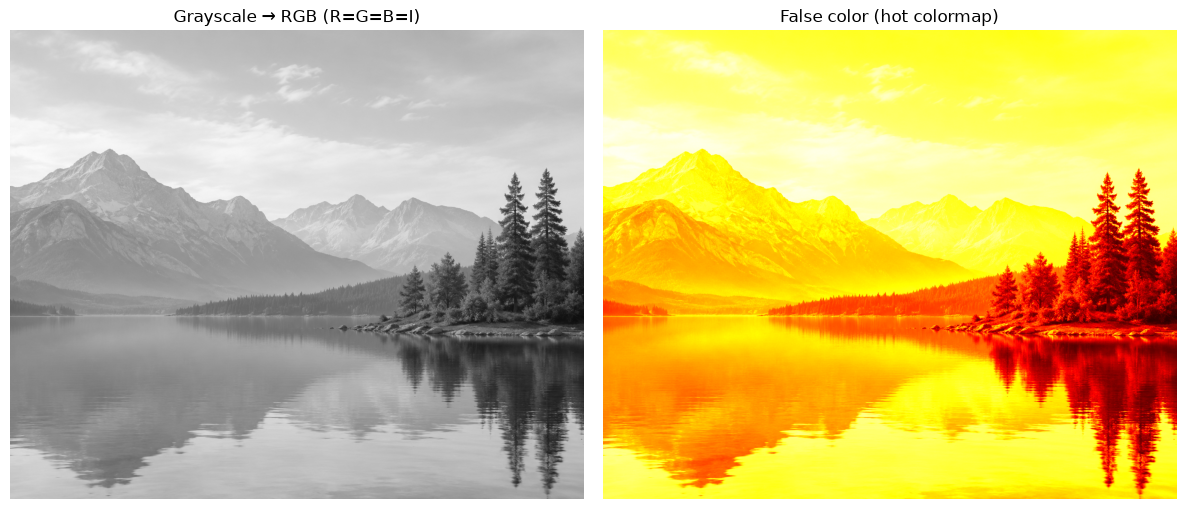

Saved GeneratedImage_comparison.png


In [27]:
img_rgb        = np.array(pixels_rgb,        dtype=np.uint8).reshape(IMAGE_HEIGHT, IMAGE_WIDTH, 3)
img_falsecolor = np.array(pixels_falsecolor, dtype=np.uint8).reshape(IMAGE_HEIGHT, IMAGE_WIDTH, 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Grayscale → RGB (R=G=B=I)")
axes[0].axis("off")
axes[1].imshow(img_falsecolor)
axes[1].set_title("False color (hot colormap)")
axes[1].axis("off")
plt.tight_layout()
plt.savefig("GeneratedImage_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved GeneratedImage_comparison.png")

In [28]:
# --- Verification: compare CUDA outputs against Python reference ---

INPUT_TXT = "/home/rashiqul/Workspace/CUDA_Practice/src/convert_to_rgb/input/input_pixels.txt"

gray_values = []
with open(INPUT_TXT, "r") as f:
    for line in f:
        gray_values.extend([int(v) for v in line.split()])

print(f"Grayscale pixels read: {len(gray_values)}  (expected {IMAGE_WIDTH * IMAGE_HEIGHT})")

# Python reference for R=G=B kernel
expected_rgb = [(v, v, v) for v in gray_values]
mismatches_rgb = sum(1 for a, b in zip(expected_rgb, pixels_rgb) if a != b)
print(f"RGB kernel mismatches       : {mismatches_rgb}")

# Python reference for hot colormap
def hot_colormap(I):
    if I < 85:
        return (I * 3, 0, 0)
    elif I < 170:
        return (255, (I - 85) * 3, 0)
    else:
        return (255, 255, (I - 170) * 3)

expected_fc = [hot_colormap(v) for v in gray_values]
mismatches_fc = sum(1 for a, b in zip(expected_fc, pixels_falsecolor) if a != b)
print(f"False-color kernel mismatches: {mismatches_fc}")

Grayscale pixels read: 1572604  (expected 1572604)
RGB kernel mismatches       : 0
False-color kernel mismatches: 0
